<a href="https://colab.research.google.com/github/kosaquito/ScoutingFutbolKosaquito/blob/main/Kosaco_ScoutMe_Clustering_Jugadores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perfiles de jugadores con K-Means — Kosaco ScoutMe

**Aplicación de la Unidad de Clustering (Aprendizaje Automático 1) al scouting de fútbol.**

Este notebook sigue la misma estructura que el Colab de la materia (*TransformarDatosParaClustering*, dataset Palmer Penguins), pero en lugar de pingüinos agrupamos **jugadores de fútbol según su perfil de juego**.

| Colab de la materia | Este notebook |
|---|---|
| Pingüinos | Jugadores |
| `flipper_length_mm`, `body_mass_g` | Recuperaciones, pases clave, regates, tiros… |
| Nulos → `dropna()` | Nulos → imputación con la mediana por posición |
| Camino A (sin escalar) vs Camino B (StandardScaler) | Camino A (totales crudos) vs Camino B (por 90 min + StandardScaler) |
| K-Means con k=3 | Método del codo + silueta para elegir k |

> ⚠️ **Los datos de este notebook son FICTICIOS** (generados al azar para practicar). En la sección 9 está explicado cómo reemplazarlos por tus propios datos de Cuarta, Reserva o Liga Santafesina.

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import unicodedata

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

## 1. Generar datos de ejemplo

En el Colab de la materia el dataset se carga con `sns.load_dataset('penguins')`. Acá **simulamos** una planilla de relevamiento como la que armarías vos: una fila por jugador con sus **totales de la temporada**.

Se generan 5 "perfiles ocultos" (el modelo **no** los conoce: la idea es ver si K-Means los redescubre solo):

- Defensor central
- Volante de recuperación
- Volante creativo
- Extremo desequilibrante
- Delantero de área

In [2]:
rng = np.random.default_rng(45)  # semilla fija: siempre los mismos datos

# Promedios POR 90 MINUTOS de cada perfil oculto
perfiles_ocultos = {
    #                       recup  duelos  aereos despejes pases_prog pases_clave regates tiros  goles
    "Defensor central":        [6.5,  6.0,   4.2,   6.5,     2.5,       0.3,      0.2,   0.4,  0.05],
    "Volante de recuperación": [8.5,  7.5,   1.8,   2.0,     3.5,       0.6,      0.6,   0.5,  0.05],
    "Volante creativo":        [4.0,  3.5,   0.6,   0.5,     7.5,       2.3,      1.8,   1.3,  0.15],
    "Extremo desequilibrante": [2.5,  3.0,   0.4,   0.3,     4.0,       1.6,      4.2,   2.4,  0.30],
    "Delantero de área":       [1.8,  3.8,   3.0,   0.5,     1.2,       0.8,      1.0,   3.6,  0.55],
}
metricas = ["recuperaciones", "duelos_ganados", "duelos_aereos_ganados", "despejes",
            "pases_progresivos", "pases_clave", "regates_exitosos", "tiros", "goles"]
posicion_de = {"Defensor central": "DEF", "Volante de recuperación": "MED",
               "Volante creativo": "MED", "Extremo desequilibrante": "DEL",
               "Delantero de área": "DEL"}

nombres = ["Juan", "Matías", "Lautaro", "Tomás", "Franco", "Nicolás", "Agustín", "Santiago",
           "Facundo", "Joaquín", "Gonzalo", "Bruno", "Thiago", "Valentín", "Ignacio", "Lucas"]
apellidos = ["Gómez", "Fernández", "Rodríguez", "López", "Martínez", "Pérez", "Sosa", "Romero",
             "Acosta", "Benítez", "Medina", "Herrera", "Aguirre", "Giménez", "Molina", "Ríos",
             "Ledesma", "Correa", "Vera", "Ojeda"]
categorias = ["Cuarta AFA", "Reserva (Proyección)", "Liga Santafesina"]

filas, usados = [], set()
for perfil, medias in perfiles_ocultos.items():
    for _ in range(30):
        while True:
            nom = f"{rng.choice(nombres)} {rng.choice(apellidos)}"
            if nom not in usados:
                usados.add(nom); break
        minutos = int(rng.integers(90, 2400))
        por90 = np.clip(rng.normal(medias, np.array(medias) * 0.22), 0, None)
        totales = np.round(por90 * minutos / 90).astype(int)
        filas.append({
            "jugador": nom,
            "categoria": rng.choice(categorias),
            "posicion": posicion_de[perfil],
            "edad": int(rng.integers(17, 23)),
            "minutos": minutos,
            **dict(zip(metricas, totales)),
            "distancia_km_p90": round(float(rng.normal(10.5, 0.7)), 2),
            "_perfil_real": perfil,   # SOLO para validar al final; nunca entra al modelo
        })

df = pd.DataFrame(filas).sample(frac=1, random_state=1).reset_index(drop=True)

# Ensuciamos los datos como pasa en la vida real:
# (a) GPS no disponible en algunos partidos -> nulos en distancia
df.loc[rng.choice(df.index, 18, replace=False), "distancia_km_p90"] = np.nan
# (b) nombres cargados con distinto formato
df.loc[3, "jugador"] = "  " + df.loc[3, "jugador"].upper() + " "
df.loc[7, "jugador"] = df.loc[7, "jugador"].lower()

df.to_csv("jugadores_ejemplo.csv", index=False)
print("Planilla generada:", df.shape)

Planilla generada: (150, 16)


## 2. Carga y exploración inicial

Igual que en el Colab: `head()`, `info()` y `describe()`. Prestá atención a los **rangos**: `minutos` va de ~90 a ~2400 y `goles` de 0 a ~15.

In [3]:
df = pd.read_csv("jugadores_ejemplo.csv")

print("Primeros registros:")
display(df.head())

print("\nInformación general (atención a los nulos):")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe().round(1))

Primeros registros:


,jugador,categoria,posicion,edad,minutos,recuperaciones,duelos_ganados,duelos_aereos_ganados,despejes,pases_progresivos,pases_clave,regates_exitosos,tiros,goles,distancia_km_p90,_perfil_real
0,Joaquín Acosta,Liga Santafesina,DEF,17,1828,158,105,83,169,67,6,4,8,1,NaN,Defensor central
1,Nicolás Giménez,Cuarta AFA,DEL,19,546,17,19,3,2,34,14,20,14,2,10.66,Extremo desequilibrante
2,Joaquín Gómez,Reserva (Proyección),MED,17,1874,85,55,11,7,132,42,26,28,4,12.23,Volante creativo
3,BRUNO MARTÍNEZ,Liga Santafesina,DEF,20,1784,93,121,49,151,56,5,3,8,1,10.56,Defensor central
4,Facundo Medina,Cuarta AFA,DEL,19,1198,23,57,35,4,12,12,15,50,10,10.18,Delantero de área



Información general (atención a los nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   jugador                150 non-null    object 
 1   categoria              150 non-null    object 
 2   posicion               150 non-null    object 
 3   edad                   150 non-null    int64  
 4   minutos                150 non-null    int64  
 5   recuperaciones         150 non-null    int64  
 6   duelos_ganados         150 non-null    int64  
 7   duelos_aereos_ganados  150 non-null    int64  
 8   despejes               150 non-null    int64  
 9   pases_progresivos      150 non-null    int64  
 10  pases_clave            150 non-null    int64  
 11  regates_exitosos       150 non-null    int64  
 12  tiros                  150 non-null    int64  
 13  goles                  150 non-null    int64  
 14  distancia_km_

,edad,minutos,recuperaciones,duelos_ganados,duelos_aereos_ganados,despejes,pases_progresivos,pases_clave,regates_exitosos,tiros,goles,distancia_km_p90
count,150.0,150.0,150.0,150.0,150.0,150.0,150.0,150.0,150.0,150.0,150.0,132.0
mean,19.5,1268.0,66.4,68.6,27.2,28.6,55.2,15.5,22.8,21.8,2.9,10.5
std,1.8,646.1,59.1,50.0,26.8,43.4,47.1,13.6,26.0,20.5,3.0,0.7
min,17.0,100.0,2.0,5.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,8.5
25%,18.0,789.2,27.0,34.0,6.2,5.0,18.0,5.0,4.0,6.2,1.0,10.0
50%,19.0,1270.0,48.0,55.0,14.0,8.0,42.0,11.5,15.0,14.0,2.0,10.5
75%,21.0,1798.5,89.8,90.8,41.8,32.8,75.5,25.2,28.0,31.8,4.0,11.0
max,22.0,2388.0,279.0,221.0,116.0,217.0,223.0,60.0,137.0,102.0,15.0,12.4


## 3. EDA: ¿cómo se reparten los jugadores?

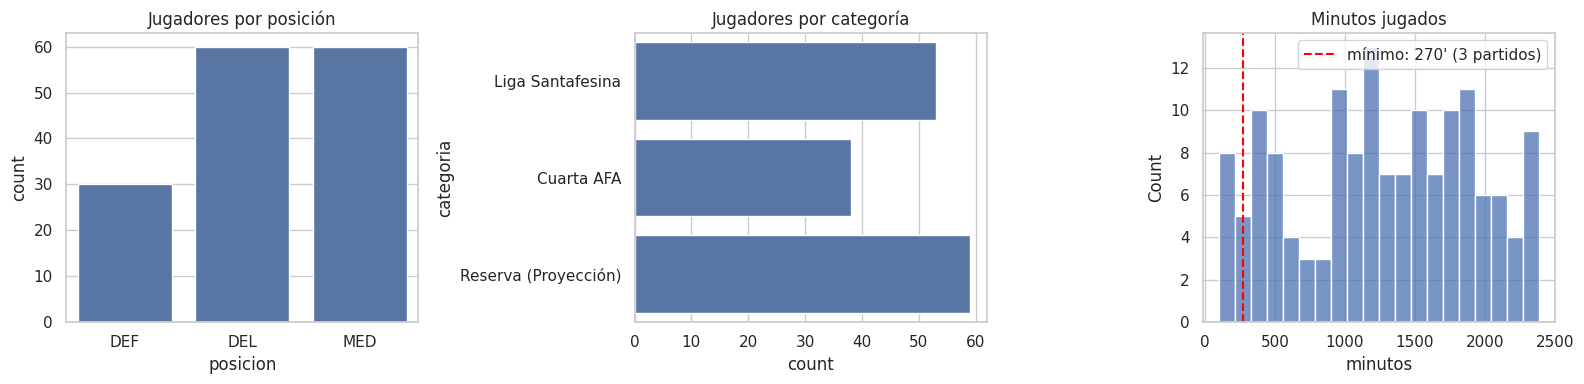

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, x="posicion", ax=axes[0]);             axes[0].set_title("Jugadores por posición")
sns.countplot(data=df, y="categoria", ax=axes[1]);            axes[1].set_title("Jugadores por categoría")
sns.histplot(data=df, x="minutos", bins=20, ax=axes[2]);      axes[2].set_title("Minutos jugados")
axes[2].axvline(270, color="red", ls="--", label="mínimo: 270' (3 partidos)")
axes[2].legend()
plt.tight_layout(); plt.show()

## 4. Limpieza

### 4.1 Normalizar nombres
El mismo jugador puede aparecer como `"JUAN GÓMEZ "` en un acta y `"juan gomez"` en otra. Sin esto, al cruzar Cuarta + Reserva + Liga lo contarías como dos personas distintas.

In [5]:
def normalizar_nombre(s):
    s = " ".join(str(s).split())                       # espacios extra
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))  # saca tildes
    return s.title()

print("Antes :", repr(df.loc[3, "jugador"]), "|", repr(df.loc[7, "jugador"]))
df["jugador"] = df["jugador"].apply(normalizar_nombre)
print("Después:", repr(df.loc[3, "jugador"]), "|", repr(df.loc[7, "jugador"]))

Antes : '  BRUNO MARTÍNEZ ' | 'lucas pérez'
Después: 'Bruno Martinez' | 'Lucas Perez'


### 4.2 Valores perdidos

En el Colab se usó `dropna()` porque eran pocos pingüinos. Acá **perderíamos 18 jugadores** por un dato que ni siquiera es clave (distancia GPS). Aplicamos lo que el Colab menciona como alternativa: **imputación**, con la **mediana de su misma posición**.

In [6]:
print("Nulos por columna:")
print(df.isnull().sum()[lambda s: s > 0])

df["distancia_km_p90"] = df.groupby("posicion")["distancia_km_p90"].transform(
    lambda s: s.fillna(s.median()))

print("\nNulos después de imputar:", int(df["distancia_km_p90"].isnull().sum()))

Nulos por columna:
distancia_km_p90    18
dtype: int64

Nulos después de imputar: 0


### 4.3 Filtro de muestra mínima (sobreajuste / muestra chica)

Un jugador con 90 minutos y 2 tiros tiene "2 tiros por partido": es ruido, no un perfil. Pedimos **al menos 270 minutos** (≈ 3 partidos completos). Es la misma lógica de *underfitting/overfitting* de la materia: no sacar conclusiones con poca evidencia.

In [7]:
MIN_MINUTOS = 270
excluidos = df[df["minutos"] < MIN_MINUTOS]
df = df[df["minutos"] >= MIN_MINUTOS].reset_index(drop=True)
print(f"Excluidos por pocos minutos: {len(excluidos)}  |  Quedan para el análisis: {len(df)}")

Excluidos por pocos minutos: 10  |  Quedan para el análisis: 140


### 4.4 Transformación clave del fútbol: métricas **por 90 minutos**

Esto es el equivalente futbolero del problema de escalas del Colab. Un titular con 2000' tiene más recuperaciones **totales** que un suplente con 400' aunque recupere mucho peor. Dividimos por minutos y multiplicamos por 90.

In [8]:
for m in metricas:
    df[f"{m}_p90"] = (df[m] / df["minutos"] * 90).round(2)

features = [f"{m}_p90" for m in metricas] + ["distancia_km_p90"]
display(df[["jugador", "minutos"] + features].head())

,jugador,minutos,recuperaciones_p90,duelos_ganados_p90,duelos_aereos_ganados_p90,despejes_p90,pases_progresivos_p90,pases_clave_p90,regates_exitosos_p90,tiros_p90,goles_p90,distancia_km_p90
0,Joaquin Acosta,1828,7.78,5.17,4.09,8.32,3.30,0.30,0.20,0.39,0.05,10.435
1,Nicolas Gimenez,546,2.80,3.13,0.49,0.33,5.60,2.31,3.30,2.31,0.33,10.660
2,Joaquin Gomez,1874,4.08,2.64,0.53,0.34,6.34,2.02,1.25,1.34,0.19,12.230
3,Bruno Martinez,1784,4.69,6.10,2.47,7.62,2.83,0.25,0.15,0.40,0.05,10.560
4,Facundo Medina,1198,1.73,4.28,2.63,0.30,0.90,0.90,1.13,3.76,0.75,10.180


## 5. Modelar: influencia de la transformación de los datos

Igual que en el Colab, comparamos dos caminos con **k = 5**:

- **Camino A:** K-Means sobre **totales crudos** (incluyendo `minutos`), sin escalar.
- **Camino B:** K-Means sobre **métricas por 90 estandarizadas** con `StandardScaler` → z = (x − μ) / σ.

In [9]:
K = 5

# CAMINO A: datos crudos
X_raw = df[["minutos"] + metricas]
kmeans_raw = KMeans(n_clusters=K, random_state=123, n_init=10)
df["cluster_raw"] = kmeans_raw.fit_predict(X_raw)

# CAMINO B: por 90 + estandarizado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
kmeans_scaled = KMeans(n_clusters=K, random_state=123, n_init=10)
df["cluster_scaled"] = kmeans_scaled.fit_predict(X_scaled)

### Visualización del contraste

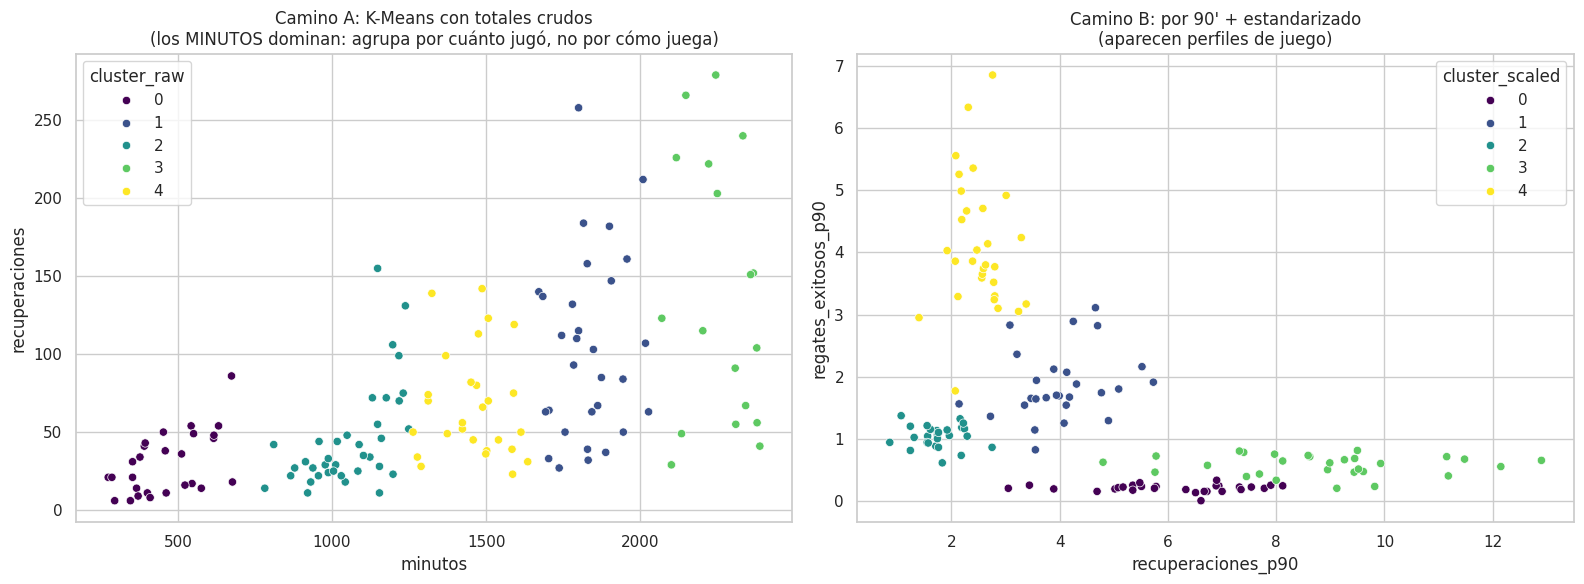

Camino A — minutos promedio por cluster (fíjate que están ordenados por minutos):
cluster_raw
0     461.0
2    1056.0
4    1457.0
1    1832.0
3    2250.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x="minutos", y="recuperaciones", hue="cluster_raw",
                palette="viridis", ax=axes[0])
axes[0].set_title("Camino A: K-Means con totales crudos\n(los MINUTOS dominan: agrupa por cuánto jugó, no por cómo juega)")

sns.scatterplot(data=df, x="recuperaciones_p90", y="regates_exitosos_p90", hue="cluster_scaled",
                palette="viridis", ax=axes[1])
axes[1].set_title("Camino B: por 90' + estandarizado\n(aparecen perfiles de juego)")

plt.tight_layout(); plt.show()

print("Camino A — minutos promedio por cluster (fíjate que están ordenados por minutos):")
print(df.groupby("cluster_raw")["minutos"].mean().sort_values().round(0).to_string())

## 6. ¿Cuántos perfiles hay? Método del codo + silueta

En el Colab se fijó k=3 porque sabíamos que había 3 especies. En scouting **no sabemos** cuántos perfiles hay, así que probamos de 2 a 10:

- **Codo (inercia):** buscamos dónde la curva deja de bajar fuerte.
- **Silueta:** entre -1 y 1; cuanto más alto, grupos más separados.

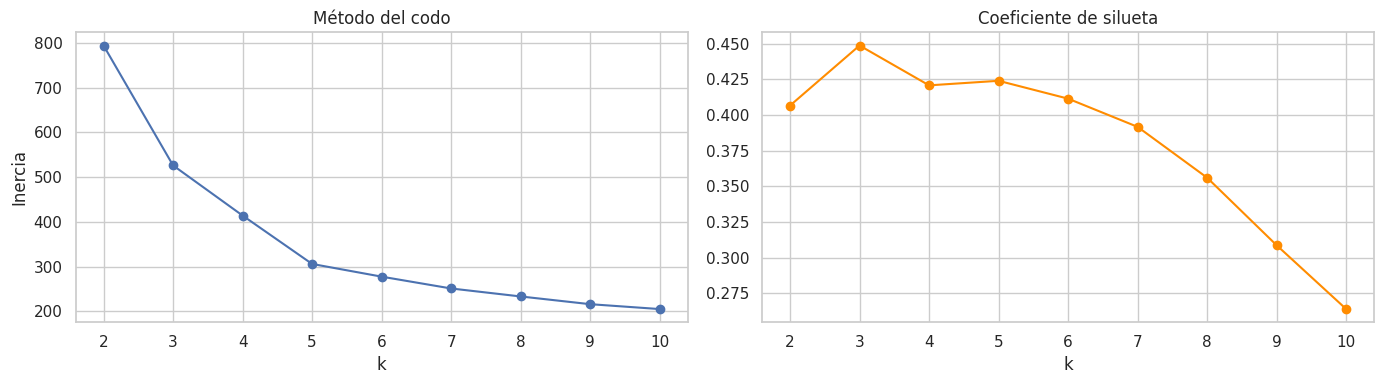

k,2,3,4,5,6,7,8,9,10
inercia,794.000,526.000,414.000,306.000,277.000,251.000,233.000,216.000,205.000
silueta,0.407,0.449,0.421,0.424,0.412,0.392,0.356,0.309,0.264


k con mejor silueta: 3


In [11]:
ks = range(2, 11)
inercias, siluetas = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=123, n_init=10).fit(X_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(ks), inercias, "o-"); axes[0].set_title("Método del codo"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inercia")
axes[1].plot(list(ks), siluetas, "o-", color="darkorange"); axes[1].set_title("Coeficiente de silueta"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.show()

display(pd.DataFrame({"k": list(ks), "inercia": np.round(inercias, 0), "silueta": np.round(siluetas, 3)}).set_index("k").T)
print(f"k con mejor silueta: {list(ks)[int(np.argmax(siluetas))]}")

### Decisión: la métrica ayuda, el criterio futbolístico decide

- Con **k = 3** la silueta es la más alta, pero agrupa en "grandes familias" (defensivos / creadores / área): demasiado general para recomendar un jugador.
- Con **k = 5** la silueta es casi igual (diferencia de ~0,02) y los grupos coinciden con **roles concretos** que un DT reconoce.

Elegimos **k = 5**. Cuando uses tus datos, repetí este razonamiento: mirá los valores cercanos al máximo y quedate con el que dé perfiles **interpretables**.

In [12]:
K_ELEGIDO = 5   # <- cambialo según tu análisis del codo y la silueta

## 7. Interpretar los perfiles (lo que le mostrás a un DT)

Un cluster "2" no le sirve a nadie. Miramos los **centroides** (el jugador "promedio" de cada grupo) y les ponemos **nombre de fútbol**.

In [13]:
modelo = KMeans(n_clusters=K_ELEGIDO, random_state=123, n_init=10).fit(X_scaled)
df["cluster"] = modelo.labels_

# Centroides en unidades reales (por 90) y en z-score (para comparar)
centroides_z = pd.DataFrame(modelo.cluster_centers_, columns=features)
centroides = pd.DataFrame(scaler.inverse_transform(modelo.cluster_centers_), columns=features)

etiquetas = {"recuperaciones_p90": "Volante de recuperación", "despejes_p90": "Defensor central",
             "pases_clave_p90": "Volante creativo", "regates_exitosos_p90": "Extremo desequilibrante",
             "goles_p90": "Delantero de área", "tiros_p90": "Delantero de área",
             "pases_progresivos_p90": "Volante creativo", "duelos_aereos_ganados_p90": "Defensor central"}

def nombrar(fila_z, ya_usados):
    for feat in fila_z.sort_values(ascending=False).index:     # rasgo más destacado primero
        nombre = etiquetas.get(feat)
        if nombre and nombre not in ya_usados:
            return nombre
    return "Perfil mixto"

nombres_cluster, usados_n = {}, set()
for c in centroides_z.index:
    nombres_cluster[c] = nombrar(centroides_z.loc[c], usados_n); usados_n.add(nombres_cluster[c])
df["perfil"] = df["cluster"].map(nombres_cluster)

tabla = centroides.copy(); tabla.index = [nombres_cluster[c] for c in tabla.index]
tabla["jugadores"] = df["perfil"].value_counts()
display(tabla.round(2))

,recuperaciones_p90,duelos_ganados_p90,duelos_aereos_ganados_p90,despejes_p90,pases_progresivos_p90,pases_clave_p90,regates_exitosos_p90,tiros_p90,goles_p90,distancia_km_p90,jugadores
Defensor central,6.08,5.81,4.28,6.99,2.49,0.30,0.20,0.41,0.04,10.52,28
Volante creativo,4.01,3.56,0.58,0.45,7.95,2.20,1.86,1.24,0.15,10.62,27
Delantero de área,1.76,3.70,3.19,0.53,1.12,0.80,1.04,3.56,0.50,10.58,26
Volante de recuperación,8.85,7.95,1.92,2.23,3.56,0.56,0.57,0.49,0.04,10.45,29
Extremo desequilibrante,2.51,2.98,0.39,0.29,3.86,1.62,4.11,2.33,0.30,10.30,30


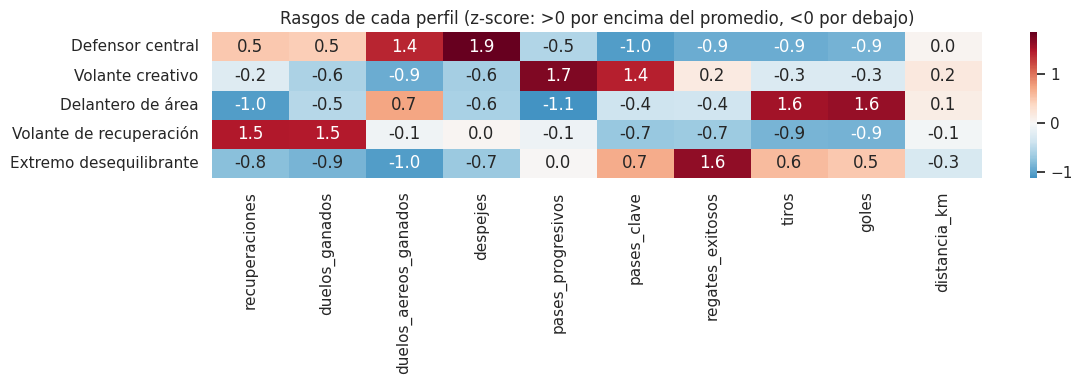

In [14]:
plt.figure(figsize=(12, 4))
hm = centroides_z.copy(); hm.index = [nombres_cluster[c] for c in hm.index]
hm.columns = [c.replace("_p90", "") for c in hm.columns]
sns.heatmap(hm, annot=True, fmt=".1f", cmap="RdBu_r", center=0)
plt.title("Rasgos de cada perfil (z-score: >0 por encima del promedio, <0 por debajo)")
plt.tight_layout(); plt.show()

### Vista general con PCA (extra)

Tenemos 10 variables y no se pueden graficar todas. PCA las resume en 2 ejes para ver si los grupos quedan separados. (PCA se ve más adelante en la carrera; acá solo lo usamos para dibujar.)

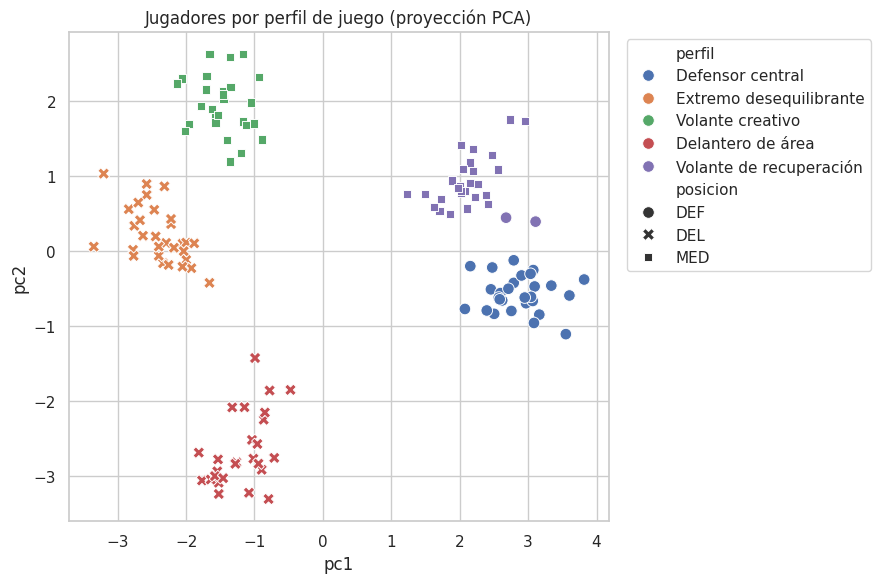

In [15]:
coords = PCA(n_components=2, random_state=0).fit_transform(X_scaled)
df["pc1"], df["pc2"] = coords[:, 0], coords[:, 1]
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="pc1", y="pc2", hue="perfil", style="posicion", s=70)
plt.title("Jugadores por perfil de juego (proyección PCA)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left"); plt.tight_layout(); plt.show()

**Lectura de scout:** fijate si aparecen jugadores con una forma (posición declarada) dentro de un color (perfil) distinto. Por ejemplo, un **DEF que cae entre los volantes de recuperación** juega como un 5 aunque figure como defensor: es exactamente el tipo de hallazgo que se puede vender a un club. Para listarlos:

In [16]:
df[(df["posicion"] == "DEF") & (df["perfil"] != "Defensor central")][["jugador", "categoria", "minutos", "perfil"]]

,jugador,categoria,minutos,perfil
25,Franco Fernandez,Cuarta AFA,394,Volante de recuperación
115,Matias Vera,Reserva (Proyección),1816,Volante de recuperación


### ¿Acertó? (validación — solo posible con datos simulados)

Como generamos los datos, sabemos el perfil real. Con datos tuyos esta celda no aplica: la validación es **mirar video** de los jugadores de cada grupo.

In [17]:
display(pd.crosstab(df["_perfil_real"], df["perfil"], rownames=["Perfil real"], colnames=["Perfil K-Means"]))
acierto = (df["_perfil_real"] == df["perfil"]).mean()
print(f"Coincidencia: {acierto:.0%}")

Perfil K-Means,Defensor central,Delantero de área,Extremo desequilibrante,Volante creativo,Volante de recuperación
Perfil real,,,,,
Defensor central,28,0,0,0,2
Delantero de área,0,26,0,0,0
Extremo desequilibrante,0,0,30,0,0
Volante creativo,0,0,0,27,0
Volante de recuperación,0,0,0,0,27


Coincidencia: 99%


## 8. Herramienta de scouting: "¿a quién se parece este jugador?"

El uso comercial más directo. Un club te dice: *"se nos va el 5, buscame alguien parecido"*. Buscamos los jugadores más cercanos en el espacio estandarizado.

In [18]:
def similares(nombre, n=5):
    i = df.index[df["jugador"] == nombre][0]
    d = euclidean_distances(X_scaled[i:i+1], X_scaled)[0]
    res = df.assign(distancia=d).drop(index=i).nsmallest(n, "distancia")
    return res[["jugador", "categoria", "edad", "minutos", "perfil", "distancia"]].round(2)

referencia = df[df["perfil"] == "Volante de recuperación"].sort_values("minutos").iloc[-1]["jugador"]
print(f"Jugadores más parecidos a {referencia}:")
display(similares(referencia))

Jugadores más parecidos a Thiago Correa:


,jugador,categoria,edad,minutos,perfil,distancia
47,Joaquin Herrera,Cuarta AFA,19,1745,Volante de recuperación,1.09
24,Facundo Vera,Reserva (Proyección),17,1197,Volante de recuperación,1.25
69,Bruno Rodriguez,Reserva (Proyección),18,632,Volante de recuperación,1.32
14,Gonzalo Fernandez,Reserva (Proyección),21,543,Volante de recuperación,1.40
111,Thiago Gimenez,Reserva (Proyección),19,1684,Volante de recuperación,1.47


### Ranking dentro de un perfil

Por ejemplo, los 5 mejores volantes de recuperación de 20 años o menos.

In [19]:
(df[(df["perfil"] == "Volante de recuperación") & (df["edad"] <= 20)]
   .sort_values("recuperaciones_p90", ascending=False)
   [["jugador", "categoria", "edad", "minutos", "recuperaciones_p90", "duelos_ganados_p90", "pases_progresivos_p90"]]
   .head(5).round(2))

,jugador,categoria,edad,minutos,recuperaciones_p90,duelos_ganados_p90,pases_progresivos_p90
109,Facundo Gimenez,Reserva (Proyección),19,1148,12.15,11.05,5.10
45,Lautaro Ojeda,Liga Santafesina,17,674,11.48,11.22,3.87
5,Agustin Aguirre,Reserva (Proyección),19,2148,11.15,6.08,3.06
120,Nicolas Fernandez,Liga Santafesina,17,453,9.93,7.75,3.77
25,Franco Fernandez,Cuarta AFA,17,394,9.82,5.94,3.20


## Exportar resultados

In [20]:
salida = df[["jugador", "categoria", "posicion", "edad", "minutos", "perfil"] + features]
salida.to_csv("perfiles_jugadores.csv", index=False)
print("Guardado: perfiles_jugadores.csv")

Guardado: perfiles_jugadores.csv


## 9. Cómo usarlo con tus propios datos

1. Armá una planilla (Excel o Google Sheets) con **una fila por jugador** y estas columnas:

| Columna | Qué es |
|---|---|
| `jugador` | Nombre y apellido |
| `categoria` | Cuarta AFA / Reserva / Liga Santafesina… |
| `posicion` | DEF / MED / DEL |
| `edad` | Años |
| `minutos` | Minutos totales jugados |
| `recuperaciones`, `duelos_ganados`, `duelos_aereos_ganados`, `despejes`, `pases_progresivos`, `pases_clave`, `regates_exitosos`, `tiros`, `goles` | **Totales** de la temporada (de actas + etiquetado de video) |
| `distancia_km_p90` | Opcional (GPS). Si falta, se imputa |

2. Exportala como CSV, subila a Colab y en la **sección 2** cambiá el nombre del archivo en `pd.read_csv(...)`.
3. **Saltá la sección 1** (generación de datos ficticios) y la celda de validación de la sección 7.
4. Si agregás o sacás métricas, actualizá la lista `metricas` y el diccionario `etiquetas`.

**Buenas prácticas:**
- Con menos de ~40 jugadores los clusters son inestables: juntá más muestra o analizá una posición por vez.
- Revisá los nombres de los perfiles: la regla automática es una ayuda, **el criterio final es tuyo** (y del video).
- Siempre informá los minutos de cada jugador junto al perfil.